In [ ]:
import jax
import jax.numpy as jnp
import optax
from jax import random
from jax.scipy.optimize import minimize

import numpy as np

import matplotlib.pyplot as plt
import math
import time

In [ ]:
# Função teórica exata
def u_exact(x, y):
    return x**2 * (x - 1)**2 * y * (y - 1)**2

activation_function = jax.nn.tanh # defines tanh as activation function

In [ ]:
# hyperparameters
width = [2] + 1*[20] + [1]
lr = 1e-3
b1 = 0.9
b2 = 0.999
eps = 1e-08
eps_root = 0.0
epochs = 20000

In [ ]:
initializer = jax.nn.initializers.glorot_normal() # Glorot initialization
key    = jax.random.split(jax.random.PRNGKey(136), len(width) - 1)
params = list()

for key, lin, lout in zip(key, width[:-1], width[1:]):
  W = initializer(key, (lin, lout), jnp.float32)
  B = initializer(key, (1, lout)  , dtype=jnp.float32)
  params.append({'W': W, 'B': B})

In [ ]:
#Initilize optimizer
optimizer = optax.adam(lr, b1, b2, eps, eps_root)
opt_state = optimizer.init(params)

In [ ]:
# Define function for forward pass
@jax.jit #Just in time compilation
def forward(xy, params):
  """xy: shape (N, 2)"""
  x = xy
  *hidden, output = params
  for layer in hidden:
    x = activation_function(x @ layer['W'] + layer['B'])

  return x @ output['W'] + output['B']

In [ ]:
def u_net(x, y, params):
    """Retorna u(x, y) da rede neural"""
    xy = jnp.array([[x, y]])
    return forward(xy, params)[0, 0]

In [ ]:
def laplacian_u(x, y, params):
    """Calcula laplaciano de u"""
    # ∂²u/∂x²
    u_xx = jax.grad(jax.grad(lambda x_: u_net(x_, y, params), 0), 0)(x)
    # ∂²u/∂y²
    u_yy = jax.grad(jax.grad(lambda y_: u_net(x, y_, params), 0), 0)(y)
    return u_xx + u_yy


In [ ]:
def du_dx(x, y, params):
    """∂u/∂x"""
    return jax.grad(lambda x_: u_net(x_, y, params), 0)(x)

def du_dy(x, y, params):
    """∂u/∂y"""
    return jax.grad(lambda y_: u_net(x, y_, params), 0)(y)


In [ ]:
def pde_rhs(x, y):
    """RHS da eq. (6): Δu(x,y) = 2(x⁴(3y-2) + x³(4-6y) + x²(6y³-12y²+9y-2) - 6x(y-1)²y + (y-1)²y)"""
    return 2 * (x**4 * (3*y - 2) + x**3 * (4 - 6*y) + x**2 * (6*y**3 - 12*y**2 + 9*y - 2)
                - 6*x*(y - 1)**2 * y + (y - 1)**2 * y)


In [ ]:
def loss_function_interior(params, xy_interior):
    """Loss da PDE no interior"""
    def residual(xy):
        x, y = xy[0], xy[1]
        lap_u = laplacian_u(x, y, params)
        rhs = pde_rhs(x, y)
        return (lap_u - rhs)**2

    residuals = jax.vmap(residual)(xy_interior)
    return jnp.mean(residuals)

def loss_bc_x0(params, xy):
    """Neumann em x=0: ∂u/∂x = 0"""
    def residual(pt):
        return du_dx(pt[0], pt[1], params)**2
    return jnp.mean(jax.vmap(residual)(xy))

def loss_bc_x1(params, xy):
    """Neumann em x=1: ∂u/∂x = 0"""
    def residual(pt):
        return du_dx(pt[0], pt[1], params)**2
    return jnp.mean(jax.vmap(residual)(xy))

def loss_bc_y0(params, xy):
    """Dirichlet em y=0: u = 0"""
    def residual(pt):
        return u_net(pt[0], pt[1], params)**2
    return jnp.mean(jax.vmap(residual)(xy))

def loss_bc_y1(params, xy):
    """Neumann em y=1: ∂u/∂y = 0"""
    def residual(pt):
        return du_dy(pt[0], pt[1], params)**2
    return jnp.mean(jax.vmap(residual)(xy))

@jax.jit
def loss_function(params, xy_interior, xy_x0, xy_x1, xy_y0, xy_y1):
    """Loss total = Loss PDE + Loss Contornos Explícitos"""
    loss_pde = loss_function_interior(params, xy_interior)
    l_x0 = loss_bc_x0(params, xy_x0)
    l_x1 = loss_bc_x1(params, xy_x1)
    l_y0 = loss_bc_y0(params, xy_y0)
    l_y1 = loss_bc_y1(params, xy_y1)

    return loss_pde + l_x0 + l_x1 + l_y0 + l_y1


In [ ]:
# ===== GERAÇÃO DE DADOS DE TREINAMENTO =====
key_f = jax.random.PRNGKey(42)
key_g = jax.random.PRNGKey(43)

N_f = 4000  # Pontos de colocação interior
N_g = 250   # Pontos na fronteira

rand_uniform = jax.random.uniform
# Pontos de colocação interior
xy_interior = rand_uniform(key_f, shape=(N_f, 2), minval=0.0, maxval=1.0)

# Pontos na fronteira separados por face
xy_x0 = jnp.column_stack([
    jnp.zeros(boundary_points_partition),
    rand_uniform(key_g, shape=(boundary_points_partition,))
])

xy_x1 = jnp.column_stack([
    jnp.ones(boundary_points_partition),
    rand_uniform(jax.random.fold_in(key_g, 1), shape=(N_g,))
])

xy_y0 = jnp.column_stack([
    jax.random.uniform(jax.random.fold_in(key_g, 2), shape=(N_g,)),
    jnp.zeros(boundary_points_partition)
])

xy_y1 = jnp.column_stack([
    jax.random.uniform(jax.random.fold_in(key_g, 3), shape=(N_g,)),
    jnp.ones(boundary_points_partition)
])


In [ ]:
# Definir a função de gradiente
grad_loss = jax.jit(jax.grad(loss_function, 0))

# Definir a função de atualização
@jax.jit
def update(opt_state, params, xy_interior, xy_x0, xy_x1, xy_y0, xy_y1):
    grads = grad_loss(params, xy_interior, xy_x0, xy_x1, xy_y0, xy_y1)
    updates, opt_state = optimizer.update(grads, opt_state)
    params = optax.apply_updates(params, updates)
    return opt_state, params

In [ ]:
# ===== TREINAMENTO COM ADAM =====
print("="*70)
print("TREINAMENTO COM ADAM")
print("="*70)
print("Iniciando treinamento...")
t0 = time.time()
for e in range(epochs):
    opt_state, params = update(opt_state, params, xy_interior, xy_x0, xy_x1, xy_y0, xy_y1)

    if e % 2000 == 0:
        loss = loss_function(params, xy_interior, xy_x0, xy_x1, xy_y0, xy_y1)
        elapsed = time.time() - t0
        print(f"{elapsed:.3f}s | Epoch {e:<6}: Loss {loss:.12f}")

elapsed_adam = time.time() - t0
loss_adam = loss_function(params, xy_interior, xy_x0, xy_x1, xy_y0, xy_y1)
print(f"{elapsed_adam:.3f}s | Epoch {epochs-1:<6}: Loss {loss_adam:.12f}")
print("Treinamento com Adam concluído!\n")

# ===== REFINAMENTO COM L-BFGS =====
print("="*70)
print("REFINAMENTO COM L-BFGS")
print("="*70)
print("Iniciando refinamento com L-BFGS...")

# Flatten params para L-BFGS
params_flat, unflatten_fn = jax.flatten_util.ravel_pytree(params)

# Definir função objetivo para L-BFGS
def objective_lbfgs(params_flat):
    params_unflat = unflatten_fn(params_flat)
    loss = loss_function(params_unflat, xy_interior, xy_x0, xy_x1, xy_y0, xy_y1)
    grad = grad_loss(params_unflat, xy_interior, xy_x0, xy_x1, xy_y0, xy_y1)
    grad_flat, _ = jax.flatten_util.ravel_pytree(grad)
    return loss

# Executar L-BFGS
t0_lbfgs = time.time()
result = minimize(
    objective_lbfgs, params_flat, method='BFGS',
    options={'maxiter': 50000}
)  # L-BFGS com até 50000 iterações
elapsed_lbfgs = time.time() - t0_lbfgs

# Unflatten params otimizados
params_final_flat = result.x
params = unflatten_fn(params_final_flat)

# Loss final após L-BFGS
loss_lbfgs = loss_function(params, xy_interior, xy_x0, xy_x1, xy_y0, xy_y1)
print(f"L-BFGS concluído em {elapsed_lbfgs:.3f}s")
print(f"Loss após L-BFGS: {loss_lbfgs:.12f}")
print(f"Número de iterações L-BFGS: {result.nit}")
print()

# ===== RESUMO DO TREINAMENTO =====
print("="*70)
print("RESUMO DO TREINAMENTO")
print("="*70)
print(f"Adam:")
print(f"  Tempo: {elapsed_adam:.3f}s")
print(f"  Epochs: {epochs}")
print(f"  Loss final: {loss_adam:.12f}")
print(f"\nL-BFGS:")
print(f"  Tempo: {elapsed_lbfgs:.3f}s")
print(f"  Iterações: {result.nit}")
print(f"  Loss final: {loss_lbfgs:.12f}")
print(f"\nMelhoria com L-BFGS:")
print(f"  Redução de loss: {(loss_adam - loss_lbfgs) / loss_adam * 100:.2f}%")
print(f"  Tempo total: {elapsed_adam + elapsed_lbfgs:.3f}s")
print("="*70 + "\n")


TREINAMENTO COM ADAM
Iniciando treinamento...
6.525s | Epoch 0     : Loss 0.611741304398
10.730s | Epoch 2000  : Loss 0.000279542088
14.906s | Epoch 4000  : Loss 0.000078391364
19.115s | Epoch 6000  : Loss 0.000056289588
23.354s | Epoch 8000  : Loss 0.000048692662
27.619s | Epoch 10000 : Loss 0.000039931991
31.911s | Epoch 12000 : Loss 0.000036517918
36.226s | Epoch 14000 : Loss 0.000030763593
40.551s | Epoch 16000 : Loss 0.000022710301
44.856s | Epoch 18000 : Loss 0.000078242221
49.124s | Epoch 19999 : Loss 0.000015537786
Treinamento com Adam concluído!

REFINAMENTO COM L-BFGS
Iniciando refinamento com L-BFGS...
L-BFGS concluído em 19.029s
Loss após L-BFGS: 0.000009423066
Número de iterações L-BFGS: 66

RESUMO DO TREINAMENTO
Adam:
  Tempo: 49.124s
  Epochs: 20000
  Loss final: 0.000015537786

L-BFGS:
  Tempo: 19.029s
  Iterações: 66
  Loss final: 0.000009423066

Melhoria com L-BFGS:
  Redução de loss: 39.35%
  Tempo total: 68.153s



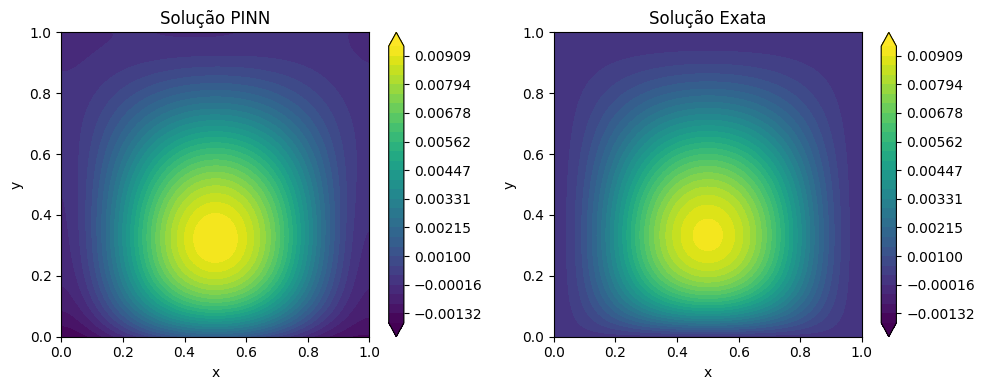

Erro máximo (absoluto): 1.70123577e-03
Erro médio (absoluto): 1.93477186e-04
Erro relativo (L2): 8.42940733e-02
Erro relativo (percentual): 8.4294%


In [ ]:
# ===== AVALIAÇÃO =====
X_test_grid = jnp.linspace(0, 1, 1000)
Y_test_grid = jnp.linspace(0, 1, 1000)
X_mesh, Y_mesh = jnp.meshgrid(X_test_grid, Y_test_grid)

# Solução da rede neural
xy_points = jnp.stack([X_mesh.ravel(), Y_mesh.ravel()], axis=-1)
u_nn_flat = forward(xy_points, params)
u_nn = u_nn_flat.reshape(X_mesh.shape)

# Solução exata
u_exact_grid = u_exact(X_mesh, Y_mesh)

# Erro
error = jnp.abs(u_nn - u_exact_grid)

v_min = min(jnp.min(u_nn), jnp.min(u_exact_grid))
v_max = max(jnp.max(u_nn), jnp.max(u_exact_grid))
niveis = np.linspace(v_min, v_max, 30)

# Plot resultados
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

im1 = axes[0].contourf(X_mesh, Y_mesh, u_nn, levels=niveis, cmap='viridis', extend='both')
axes[0].set_title('Solução PINN')
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')
plt.colorbar(im1, ax=axes[0])

im2 = axes[1].contourf(X_mesh, Y_mesh, u_exact_grid, levels=niveis, cmap='viridis', extend='both')
axes[1].set_title('Solução Exata')
axes[1].set_xlabel('x')
axes[1].set_ylabel('y')
plt.colorbar(im2, ax=axes[1])

plt.tight_layout()
plt.show()

erro_maximo = jnp.max(error)
erro_medio = jnp.mean(error)

# Erro relativo
norma_exata = jnp.sqrt(jnp.sum(u_exact_grid**2))
norma_erro = jnp.sqrt(jnp.sum(error**2))
erro_relativo = norma_erro / norma_exata

print(f"Erro máximo (absoluto): {erro_maximo:.8e}")
print(f"Erro médio (absoluto): {erro_medio:.8e}")
print(f"Erro relativo (L2): {erro_relativo:.8e}")
print(f"Erro relativo (percentual): {erro_relativo * 100:.4f}%")



In [ ]:
# ===== MEDIR TEMPO DE AVALIAÇÃO =====
t_eval_start = time.time()
xy_points = jnp.stack([X_mesh.ravel(), Y_mesh.ravel()], axis=-1)
u_nn_flat = forward(xy_points, params)
u_nn = u_nn_flat.reshape(X_mesh.shape)
time_evaluation = time.time() - t_eval_start

# ===== CONTAR PARÂMETROS =====
params_flat_final, _ = jax.flatten_util.ravel_pytree(params)
num_params = len(params_flat_final)

# ===== SALVAR RESULTADOS =====
results = {
    'architecture': width,
    'error_relativo': float(erro_relativo),
    'time_training': float(elapsed_adam + elapsed_lbfgs),
    'time_evaluation': float(time_evaluation),
    'num_params': int(num_params),
    'u_nn': u_nn,
    'u_exact': u_exact_grid,
    'error': error
}

np.savez(f'pinn_result_{width}.npz', **results)